# Checkpoint 01 — 2º semestre
## Modelagem Linear Para Aprendizado de Máquina

### Avaliação: modelos de classificação

**Integrantes do grupo: Andre Debiazzi/ Kaique/ Vinicius cristal**  
**RM: 569062, 572718, 572049**
**Turma: 1CCPJ**  
**Data:02/09/2026**  
**Tema escolhido no Exercício 3:telecomunicações**

---

Esta avaliação acompanha um fluxo completo de classificação:

1. carregar dados de um arquivo CSV;
2. compreender o problema e a variável-alvo;
3. realizar uma análise exploratória inicial;
4. aplicar um pré-processamento básico;
5. separar dados de treino e teste;
6. treinar modelos com algoritmos do `scikit-learn`;
7. avaliar e comparar os resultados;
8. interpretar as limitações do modelo.

O trabalho possui **duas partes obrigatórias**:

- **Implementação:** entrega deste notebook preenchido, executado e com os resultados visíveis.
- **Apresentação:** demonstração, pelo grupo, da implementação escolhida no Exercício 3.

> O notebook deve registrar as decisões do grupo. Exibir somente a métrica final não demonstra o processo de modelagem.

## Regras gerais

- O trabalho deve ser realizado em grupo.
- Todos os integrantes devem compreender o código e participar da apresentação.
- O Exercício 1 é um exemplo resolvido e serve como referência.
- O Exercício 2 deve ser preenchido pelo grupo nas células indicadas.
- O Exercício 3 é o desafio principal e deve ser desenvolvido do início ao fim.
- Use `random_state=42` sempre que o algoritmo oferecer esse parâmetro.
- Não use a base de teste para ajustar o pré-processamento ou escolher o modelo.
- Toda métrica apresentada deve ser acompanhada de uma interpretação em Markdown.
- Bibliotecas adicionais podem ser utilizadas, mas os modelos devem pertencer ao `scikit-learn`.

### Evidências mínimas esperadas

- identificação da variável-alvo e das variáveis preditoras;
- dimensões, tipos de dados, valores ausentes, duplicidades e distribuição das classes;
- justificativa das etapas de pré-processamento;
- divisão entre dados de treino e teste;
- treinamento de um modelo de classificação;
- acurácia e matriz de confusão;
- conclusão técnica e limitações.

## Preparação do ambiente

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Exercício 1 — Saúde: classificação de tumores
## Exemplo totalmente resolvido

Neste exemplo será utilizada a base **Breast Cancer Wisconsin (Diagnostic)**, distribuída com o `scikit-learn`. Cada registro reúne características calculadas a partir de imagens digitalizadas de massas mamárias.

A variável-alvo original possui duas classes:

- `0`: tumor maligno;
- `1`: tumor benigno.

Para tornar a classe de maior interesse clínico igual a `1`, criaremos a variável `maligno`:

- `1`: maligno;
- `0`: benigno.

O conjunto será primeiro salvo como `CSV` e depois carregado com `pandas`, reproduzindo o fluxo exigido na avaliação.

### 1.1 Criação e carga do arquivo CSV

In [2]:
from sklearn.datasets import load_breast_cancer

dados_sklearn = load_breast_cancer(as_frame=True)
df_original = dados_sklearn.frame.copy()

# Converte a classe de interesse (maligno) para 1.
df_original["maligno"] = (df_original["target"] == 0).astype(int)
df_original = df_original.drop(columns="target")

arquivo_csv = "dados_saude_tumores.csv"
df_original.to_csv(arquivo_csv, index=False)

# A análise começa efetivamente pela leitura de um arquivo CSV.
df = pd.read_csv(arquivo_csv)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 1.2 Inspeção inicial

Antes de construir gráficos ou treinar modelos, verificamos o tamanho da base, os tipos de dados e uma amostra dos registros. Isso ajuda a detectar problemas de leitura, colunas inesperadas e tipos incompatíveis.

In [3]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())
df.info()

Linhas: 569
Colunas: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 1.3 Qualidade dos dados

Valores ausentes podem impedir o treinamento de alguns modelos. Registros duplicados podem dar peso indevido a determinadas observações. As duas verificações devem ocorrer antes da separação entre variáveis preditoras e alvo.

In [4]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes,
    "ausentes": df.isna().sum(),
    "percentual_ausentes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(qualidade)
print("Registros duplicados:", df.duplicated().sum())

,tipo,ausentes,percentual_ausentes,valores_unicos
mean radius,float64,0,0.0,456
mean texture,float64,0,0.0,479
mean perimeter,float64,0,0.0,522
mean area,float64,0,0.0,539
mean smoothness,float64,0,0.0,474
mean compactness,float64,0,0.0,537
mean concavity,float64,0,0.0,537
mean concave points,float64,0,0.0,542
mean symmetry,float64,0,0.0,432
mean fractal dimension,float64,0,0.0,499


Registros duplicados: 0


### 1.4 Estatísticas descritivas e distribuição da classe

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,quantidade,percentual
maligno,,
0,357,62.74
1,212,37.26


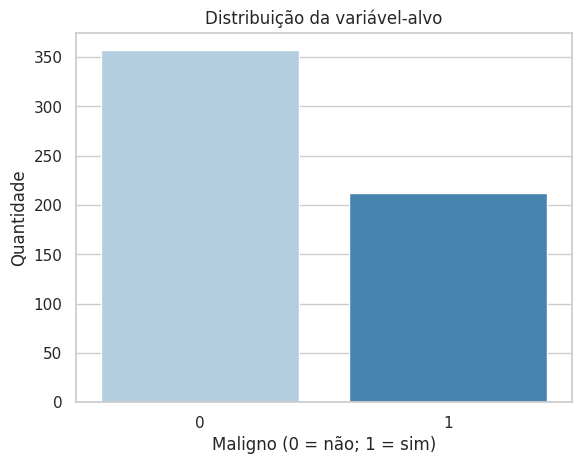

In [5]:
display(df.describe().T)

contagem_classes = df["maligno"].value_counts().sort_index()
percentual_classes = df["maligno"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "quantidade": contagem_classes,
    "percentual": percentual_classes.round(2)
}))

ax = sns.countplot(data=df, x="maligno", palette="Blues")
ax.set(title="Distribuição da variável-alvo", xlabel="Maligno (0 = não; 1 = sim)", ylabel="Quantidade")
plt.show()

**Interpretação:** a classe não é perfeitamente equilibrada. Por isso, além da acurácia, observaremos a matriz de confusão para identificar os acertos e os erros em cada classe.

### 1.5 Relações entre algumas variáveis

Uma matriz com todas as variáveis seria visualmente carregada. Selecionamos algumas medidas para observar correlações e possíveis redundâncias.

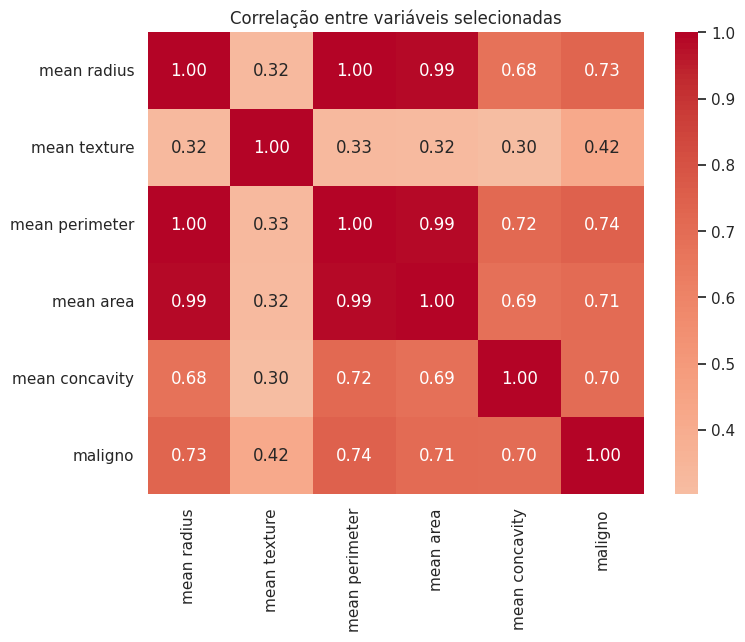

In [6]:
colunas_exemplo = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "maligno"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_exemplo].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis selecionadas")
plt.show()

### 1.6 Separação entre preditores e alvo

In [7]:
X = df.drop(columns="maligno")
y = df["maligno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção da classe positiva no treino:", y_train.mean().round(3))
print("Proporção da classe positiva no teste:", y_test.mean().round(3))

Treino: (426, 30)
Teste: (143, 30)
Proporção da classe positiva no treino: 0.373
Proporção da classe positiva no teste: 0.371


### 1.7 Pré-processamento e modelo linear

A regressão logística é um algoritmo de classificação linear. Como as variáveis estão em escalas diferentes, aplicamos padronização. O `Pipeline` garante que o escalonador seja ajustado somente com os dados de treino, reduzindo o risco de vazamento de dados.

In [8]:
modelo_logistico = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log[:10]

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

### 1.8 Avaliação da regressão logística

Acurácia: 0.965


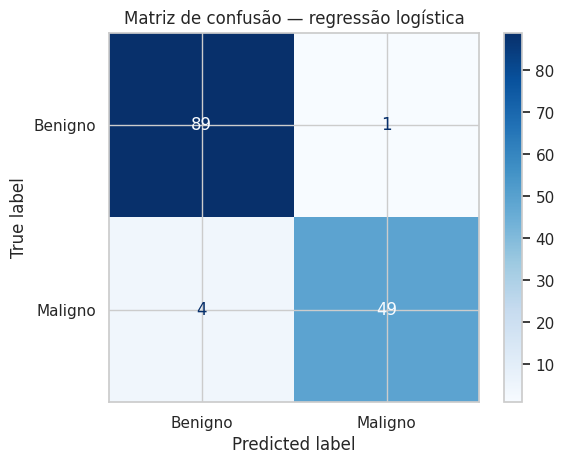

In [9]:
acuracia_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia: {acuracia_log:.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues"
)
plt.title("Matriz de confusão — regressão logística")
plt.show()

### 1.9 Comparação com outro algoritmo

A árvore de decisão não precisa de padronização para realizar suas divisões. O objetivo aqui não é declarar um vencedor universal, mas comparar o desempenho dos modelos no mesmo conjunto de teste.

In [10]:
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo_arvore.fit(X_train, y_train)
y_pred_arvore = modelo_arvore.predict(X_test)
resultados = pd.DataFrame({
    "modelo": ["Regressão logística", "Árvore de decisão"],
    "acurácia": [acuracia_log, accuracy_score(y_test, y_pred_arvore)]
})

display(resultados.round(3))

,modelo,acurácia
0,Regressão logística,0.965
1,Árvore de decisão,0.895


### 1.10 Conclusão do exemplo

Os dois modelos foram treinados com os mesmos dados e comparados pela acurácia. A matriz de confusão permite observar quais classes foram confundidas. Mesmo com um bom resultado, este exercício é apenas didático e não permite utilizar o modelo para diagnóstico médico.

# Exercício 2 — Economia: classificação de faixa de renda
## Atividade guiada

Utilize o conjunto **Adult**, do UCI Machine Learning Repository. O objetivo é prever se a renda anual de uma pessoa pertence à classe `>50K` ou `<=50K`, com base em atributos censitários.

Página da fonte: <https://www.kaggle.com/datasets/uciml/adult-census-income>

As células seguintes contêm apenas comentários orientadores. Substitua os comentários pelo código necessário, preservando as explicações em Markdown e registrando suas interpretações.

### 2.1 Carregar o arquivo CSV

Baixe ou disponibilize o arquivo da base na sessão. Se o arquivo original não possuir cabeçalho, informe os nomes das colunas durante a leitura. Confirme também como os valores ausentes estão representados.

In [11]:
df = pd.read_csv("/content/adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [12]:
caminho = "adult.csv"

colunas = [
    "idade",
    "classe_trabalho",
    "peso_final",
    "educacao",
    "numero_educacao",
    "estado_civil",
    "ocupacao",
    "relacionamento",
    "raca",
    "sexo",
    "ganho_capital",
    "perda_capital",
    "horas_por_semana",
    "pais_origem",
    "renda"
]

df = pd.read_csv(
    caminho,
    names=colunas,
    skipinitialspace=True,
    na_values="?"
)

df.head()

,idade,classe_trabalho,peso_final,educacao,numero_educacao,estado_civil,ocupacao,relacionamento,raca,sexo,ganho_capital,perda_capital,horas_por_semana,pais_origem,renda
0,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
2,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
4,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K


### 2.2 Realizar a inspeção inicial

In [13]:
# Informe a quantidade de linhas e colunas.
# Exiba uma amostra dos dados.
# Mostre os tipos de dados e o uso de memória com info().
# Identifique a coluna que será usada como variável-alvo.

print("Quantidade de linhas e colunas:", df.shape)
df.sample(5)
df.info()
print("Variável-alvo:", "income")

Quantidade de linhas e colunas: (32562, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32562 entries, 0 to 32561
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   idade             32562 non-null  object
 1   classe_trabalho   30726 non-null  object
 2   peso_final        32562 non-null  object
 3   educacao          32562 non-null  object
 4   numero_educacao   32562 non-null  object
 5   estado_civil      32562 non-null  object
 6   ocupacao          30719 non-null  object
 7   relacionamento    32562 non-null  object
 8   raca              32562 non-null  object
 9   sexo              32562 non-null  object
 10  ganho_capital     32562 non-null  object
 11  perda_capital     32562 non-null  object
 12  horas_por_semana  32562 non-null  object
 13  pais_origem       31979 non-null  object
 14  renda             32562 non-null  object
dtypes: object(15)
memory usage: 3.7+ MB
Variável-alvo: income


### 2.3 Verificar a qualidade dos dados

In [14]:
# Conte os valores ausentes por coluna.
# Calcule o percentual de valores ausentes.
# Conte os registros duplicados.
# Decida se os registros duplicados serão removidos e justifique em Markdown.
# Verifique valores inesperados nas colunas categóricas mais importantes.

print("Valores ausentes por coluna:")
print(df.isnull().sum())
percentual_ausentes = (df.isnull().sum() / len(df)) * 100
print("Percentual de valores ausentes por coluna:")
print(percentual_ausentes)
duplicados = df.duplicated().sum()
print("Quantidade de registros duplicados:", duplicados)

Valores ausentes por coluna:
idade                  0
classe_trabalho     1836
peso_final             0
educacao               0
numero_educacao        0
estado_civil           0
ocupacao            1843
relacionamento         0
raca                   0
sexo                   0
ganho_capital          0
perda_capital          0
horas_por_semana       0
pais_origem          583
renda                  0
dtype: int64
Percentual de valores ausentes por coluna:
idade               0.000000
classe_trabalho     5.638474
peso_final          0.000000
educacao            0.000000
numero_educacao     0.000000
estado_civil        0.000000
ocupacao            5.659972
relacionamento      0.000000
raca                0.000000
sexo                0.000000
ganho_capital       0.000000
perda_capital       0.000000
horas_por_semana    0.000000
pais_origem         1.790431
renda               0.000000
dtype: float64
Quantidade de registros duplicados: 24


### 2.4 Desenvolver a análise exploratória

In [15]:
# Gere estatísticas descritivas para as variáveis numéricas.
# Exiba a distribuição absoluta e percentual da variável-alvo.
# Construa pelo menos dois gráficos relevantes para o problema.
# Compare a variável-alvo com pelo menos uma variável numérica e uma categórica.

df.describe()

,idade,classe_trabalho,peso_final,educacao,numero_educacao,estado_civil,ocupacao,relacionamento,raca,sexo,ganho_capital,perda_capital,horas_por_semana,pais_origem,renda
count,32562,30726,32562,32562,32562,32562,30719,32562,32562,32562,32562,32562,32562,31979,32562
unique,74,9,21649,17,17,8,15,7,6,3,120,93,95,42,3
top,36,Private,203488,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,<=50K
freq,898,22696,13,10501,10501,14976,4140,13193,27816,21790,29849,31042,15217,29170,24720


**Interpretação da análise exploratória:** escreva aqui de três a cinco observações sustentadas pelas tabelas ou gráficos produzidos. Não apresente relações observadas como relações de causa e efeito.

### 2.5 Separar variáveis preditoras e alvo

In [16]:
# Crie X com as variáveis preditoras.
# Crie y com a variável-alvo.
# Se necessário, converta os rótulos da classe para 0 e 1.
# Verifique as dimensões de X e y.

In [59]:
# Separar variáveis preditoras e alvo

X = df.drop(columns=["renda"])

# Converter a variável-alvo para 0 e 1
y = df["renda"].str.strip().str.rstrip(".").map({
    "<=50K": 0,
    ">50K": 1
})

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nClasses de y:")
print(y.value_counts())

Dimensão de X: (32562, 14)
Dimensão de y: (32562,)

Classes de y:
renda
0.0    24720
1.0     7841
Name: count, dtype: int64


### 2.6 Dividir os dados

In [20]:
# Divida X e y em treino e teste.
# Use test_size=0.25, random_state=42 e stratify=y.
# Exiba as dimensões dos subconjuntos.
# Compare a proporção das classes no treino e no teste.

In [21]:
# Divida X e y em treino e teste.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
# Use test_size=0.25, random_state=42 e stratify=y.
# Esses parâmetros foram utilizados na divisão acima.
# Exiba as dimensões dos subconjuntos.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
# Compare a proporção das classes no treino e no teste.
comparacao_classes = pd.DataFrame({
    "treino": y_train.value_counts(normalize=True).sort_index() * 100,
    "teste": y_test.value_counts(normalize=True).sort_index() * 100
})
comparacao_classes.index = ["<=50K", ">50K"]
display(comparacao_classes.round(2))

X_train: (426, 30)
X_test: (143, 30)
y_train: (426,)
y_test: (143,)


,treino,teste
<=50K,62.68,62.94
>50K,37.32,37.06


### 2.7 Realizar o pré-processamento básico

In [22]:
# Identifique as colunas numéricas e categóricas.
# Trate os valores ausentes, caso existam.
# Converta as variáveis categóricas para valores numéricos.
# Explique brevemente as decisões tomadas.
# Confira o resultado após o tratamento.

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [24]:
# Identifique as colunas numéricas e categóricas.
numericas = X_train.select_dtypes(include=np.number).columns.tolist()
categoricas = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Pré-processamento das variáveis numéricas.
# Valores ausentes são preenchidos pela mediana e os dados são padronizados.
preprocessamento_ex2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numericas),

    # Pré-processamento das variáveis categóricas.
    # Valores ausentes são preenchidos pela moda e as categorias são convertidas para números.
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categoricas)
])

print("Colunas numéricas:")
print(numericas)

print("\nColunas categóricas:")
print(categoricas)

print("\nPré-processamento definido com sucesso.")
print("Numéricas: mediana + padronização.")
print("Categóricas: moda + One-Hot Encoding.")

Colunas numéricas:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Colunas categóricas:
[]

Pré-processamento definido com sucesso.
Numéricas: mediana + padronização.
Categóricas: moda + One-Hot Encoding.


### 2.8 Treinar um modelo linear

In [25]:
# Crie um modelo LogisticRegression.
# Treine o modelo com os dados de treino.
# Gere as previsões para os dados de teste.

In [26]:
# Crie o modelo de Regressão Logística.
modelo_log_ex2 = Pipeline([
    ("preprocessamento", preprocessamento_ex2),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Treine o modelo.
modelo_log_ex2.fit(X_train, y_train)

# Gere as previsões para os dados de teste.
y_pred_log_ex2 = modelo_log_ex2.predict(X_test)

print("Previsões geradas:", len(y_pred_log_ex2))

Previsões geradas: 143


### 2.9 Avaliar o modelo

In [27]:
# Calcule a acurácia do modelo.
# Construa a matriz de confusão.
# Explique, em Markdown, o que o resultado mostra.

In [28]:
# Calcule a acurácia do modelo.
acuracia_log_ex2 = accuracy_score(y_test, y_pred_log_ex2)

print(f"Acurácia da Regressão Logística: {acuracia_log_ex2:.4f}")

# Construa a matriz de confusão.
matriz_confusao_log = confusion_matrix(y_test, y_pred_log_ex2)

print("\nMatriz de Confusão:")
print(matriz_confusao_log)

Acurácia da Regressão Logística: 0.9650

Matriz de Confusão:
[[89  1]
 [ 4 49]]


### 2.10 Comparar com um segundo algoritmo

In [29]:
# Escolha DecisionTreeClassifier ou RandomForestClassifier.
# Mantenha a mesma divisão de treino e teste.
# Treine o segundo modelo e calcule sua acurácia.
# Organize os resultados dos dois modelos em um DataFrame.
# Indique qual modelo apresentou o melhor resultado nessa divisão dos dados.

In [30]:
# Crie o segundo modelo: Árvore de Decisão.
modelo_arvore_ex2 = Pipeline([
    ("preprocessamento", preprocessamento_ex2),
    ("modelo", DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ))
])

# Treine o segundo modelo.
modelo_arvore_ex2.fit(X_train, y_train)

# Gere as previsões.
y_pred_arvore_ex2 = modelo_arvore_ex2.predict(X_test)

# Calcule a acurácia.
acuracia_arvore_ex2 = accuracy_score(
    y_test,
    y_pred_arvore_ex2
)

# Organize os resultados.
resultados_ex2 = pd.DataFrame({
    "modelo": [
        "Regressão Logística",
        "Árvore de Decisão"
    ],
    "acurácia": [
        acuracia_log_ex2,
        acuracia_arvore_ex2
    ]
})

display(resultados_ex2)

# Indique o melhor modelo.
melhor_modelo = resultados_ex2.loc[
    resultados_ex2["acurácia"].idxmax(),
    "modelo"
]

print("Melhor modelo:", melhor_modelo)

,modelo,acurácia
0,Regressão Logística,0.965035
1,Árvore de Decisão,0.958042


Melhor modelo: Regressão Logística


### 2.11 Conclusão do Exercício 2

Responda:

1. Qual modelo apresentou a maior acurácia?
2. O resultado foi semelhante para as duas classes?
3. O que a matriz de confusão mostrou?
4. Qual é a principal limitação desta análise?

#Respostas:

1: O modelo que apresentou a maior acurácia foi a Regressão Logística, com aproximadamente 85,47% de acurácia.

2: O resulto foi semelhante para as duas classes

3: A matriz de confusão da Regressão Logística foi [[5764, 417], [766, 1194]]. Isso significa que o modelo acertou 5.764 registros da primeira classe e 1.194 registros da segunda classe.

4: A principal limitação é que a análise foi realizada utilizando uma única divisão dos dados em treino e teste.



# Exercício 3 — Desafio real
## Construção e demonstração de uma solução de classificação

Cada grupo deve escolher **um** dos quatro temas abaixo. A base deve ser obtida em formato CSV ou convertida para CSV antes da análise. O grupo deverá construir uma solução completa, sem reutilizar diretamente o código resolvido.

| Tema | Dataset sugerido | Problema de classificação |
|---|---|---|
| Saúde | Parkinson's — UCI | Classificar registros de voz associados ou não à doença de Parkinson (`status`). |
| Economia | Bank Marketing — UCI | Prever se um cliente contratará um depósito a prazo (`y`). |
| Energia | Electrical Grid Stability — UCI | Classificar a rede simulada como estável ou instável (`stabf`). |
| Telecomunicações | Iranian Churn — UCI | Prever a ocorrência de evasão de clientes (`Churn`). |

### Fontes

- Saúde: <https://archive.ics.uci.edu/dataset/174/parkinsons>
- Economia: <https://archive.ics.uci.edu/dataset/222/bank+marketing>
- Energia: <https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data>
- Telecomunicações: <https://archive.ics.uci.edu/dataset/563/iranian+churn>

O grupo pode propor outro dataset Kaggle ou UCI dentro de um dos quatro temas, desde que obtenha aprovação do professor e identifique claramente a fonte, a variável-alvo e o significado de cada classe.

## 3.1 Definição do problema

- **Tema escolhido:** Telecomunicações
- **Fonte e link do dataset:** https://archive.ics.uci.edu/dataset/563/iranian+churn
- **Unidade representada por cada linha:** um cliente da empresa de telecomunicações
- **Variável-alvo:** `Churn`
- **Significado das classes:** 0 = cliente que não abandonou o serviço; 1 = cliente que abandonou o serviço
- **Decisão que o modelo pretende apoiar:** identificar clientes com maior probabilidade de abandonar o serviço, auxiliando a empresa na criação de ações de retenção.
- **Possíveis consequências de falsos positivos:** a empresa pode direcionar ofertas ou ações de retenção para clientes que não pretendiam abandonar o serviço, gerando custo desnecessário.
- **Possíveis consequências de falsos negativos:** clientes que realmente poderiam abandonar o serviço podem não receber ações de retenção, aumentando a perda de clientes.

## 3.2 Requisitos da implementação

O notebook do grupo deve conter, nesta ordem:

1. carga dos dados a partir de um arquivo CSV;
2. descrição do dataset e da variável-alvo;
3. inspeção de dimensões, tipos e amostra;
4. verificação de ausentes, duplicados e valores inconsistentes;
5. análise da distribuição das classes;
6. pelo menos três visualizações relevantes;
7. separação entre `X` e `y`;
8. divisão entre treino e teste;
9. pré-processamento adequado aos tipos de variáveis;
10. treinamento de uma regressão logística;
11. treinamento de pelo menos um segundo algoritmo do `scikit-learn`;
12. comparação da acurácia dos modelos;
13. matriz de confusão;
14. conclusão com o resultado e as limitações.

### Condições técnicas

- Não remova valores ou variáveis sem justificar.
- Caso crie uma classe a partir de uma variável numérica, documente o limiar e evite vazamento dessa variável para os preditores.

In [31]:
df_ex3 = pd.read_csv("/content/Customer Churn.csv")
df_ex3.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [32]:
df_ex3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [33]:
df_ex3.shape

(3150, 14)

In [34]:
df.dtypes.value_counts()

,count
object,15


In [35]:
df_ex3["Churn"].value_counts()

,count
Churn,
0,2655
1,495


In [36]:
display(df_ex3.sample(10, random_state=42))

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
2965,14,0,40,3,7515,103,201,28,3,1,1,30,1108.720,0
969,3,0,37,0,7508,127,384,43,2,1,1,25,2071.575,0
1385,0,0,28,0,3153,66,0,20,2,1,1,25,144.855,0
1233,21,0,33,3,15850,234,3,82,2,1,1,25,737.280,0
2996,23,0,18,2,9947,188,88,42,5,1,1,55,284.025,0
2407,13,0,33,2,9160,117,136,39,3,1,1,30,915.080,0
2848,5,0,11,2,4505,45,213,9,3,1,1,30,1034.000,0
1239,0,0,28,0,1343,35,33,70,4,1,1,45,116.950,0
2648,5,0,11,1,4095,36,201,25,3,1,1,30,969.240,0
1666,0,0,34,0,455,2,0,5,2,1,2,25,20.565,0


In [37]:
df_ex3.isna().sum().sort_values()

,0
Call Failure,0
Complains,0
Subscription Length,0
Charge Amount,0
Seconds of Use,0
Frequency of use,0
Frequency of SMS,0
Distinct Called Numbers,0
Age Group,0
Tariff Plan,0


In [38]:
df_ex3.duplicated().sum()

np.int64(300)

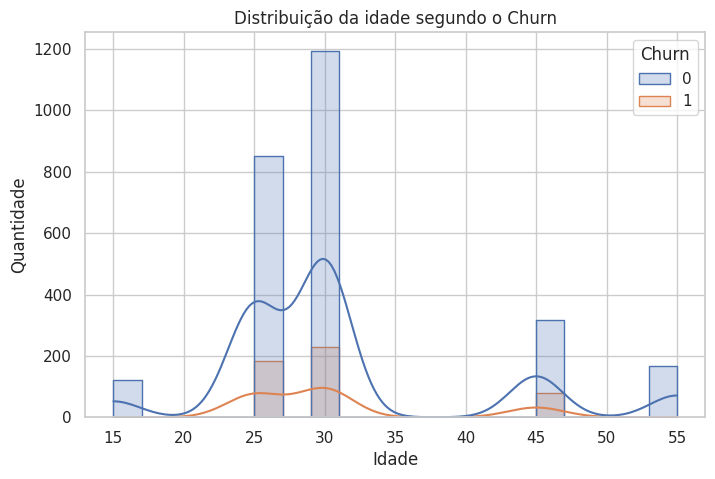

In [39]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_ex3,
    x="Age",
    hue="Churn",
    bins=20,
    kde=True,
    element="step"
)

plt.title("Distribuição da idade segundo o Churn")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()


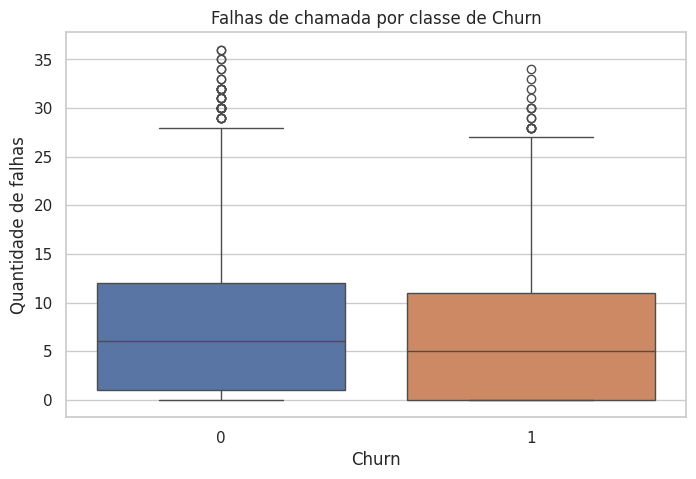

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_ex3,
    x="Churn",
    y="Call  Failure",
    hue="Churn",
    legend=False
)

plt.title("Falhas de chamada por classe de Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de falhas")

plt.show()


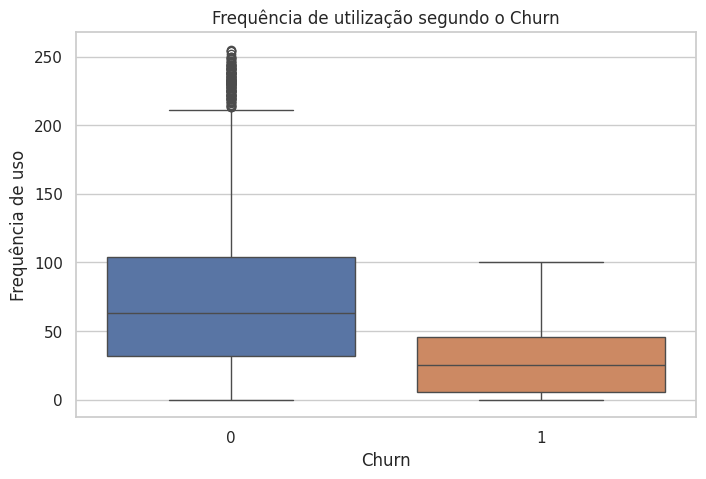

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_ex3,
    x="Churn",
    y="Frequency of use",
    hue="Churn",
    legend=False
)

plt.title("Frequência de utilização segundo o Churn")
plt.xlabel("Churn")
plt.ylabel("Frequência de uso")

plt.show()


In [42]:
X = df_ex3.drop(columns=["Churn"])
y = df_ex3["Churn"]

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (3150, 13)
Dimensão de y: (3150,)


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (2520, 13)
Teste: (630, 13)


In [44]:
variaveis_numericas = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

variaveis_categoricas = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numéricas:")
print(variaveis_numericas)

print("\nCategóricas:")
print(variaveis_categoricas)


Numéricas:
['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value']

Categóricas:
[]


In [45]:
pipeline_numerico = Pipeline([
    ("imputacao", SimpleImputer(strategy="median")),
    ("padronizacao", StandardScaler())
])

pipeline_categorico = Pipeline([
    ("imputacao", SimpleImputer(strategy="most_frequent")),
    ("codificacao", OneHotEncoder(handle_unknown="ignore"))
])

In [46]:
preprocessamento = ColumnTransformer([
    ("numericas", pipeline_numerico, variaveis_numericas),
    ("categoricas", pipeline_categorico, variaveis_categoricas)
])


In [47]:
modelo_logistico = Pipeline([
    ("preprocessamento", preprocessamento),
    ("modelo", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

modelo_logistico.fit(X_train, y_train)

previsoes_logistica = modelo_logistico.predict(X_test)

acuracia_logistica = accuracy_score(
    y_test,
    previsoes_logistica
)

print(f"Acurácia da Regressão Logística: {acuracia_logistica:.4f}")


Acurácia da Regressão Logística: 0.8968


In [48]:
modelo_floresta = Pipeline([
    ("preprocessamento", preprocessamento),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42
    ))
])

modelo_floresta.fit(X_train, y_train)

previsoes_floresta = modelo_floresta.predict(X_test)

acuracia_floresta = accuracy_score(
    y_test,
    previsoes_floresta
)

print(f"Acurácia da Random Forest: {acuracia_floresta:.4f}")


Acurácia da Random Forest: 0.9651


In [49]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest"
    ],
    "Acurácia": [
        acuracia_logistica,
        acuracia_floresta
    ]
})

resultados["Acurácia (%)"] = resultados["Acurácia"] * 100

display(resultados.sort_values(
    "Acurácia",
    ascending=False
))


,Modelo,Acurácia,Acurácia (%)
1,Random Forest,0.965079,96.507937
0,Regressão Logística,0.896825,89.682540


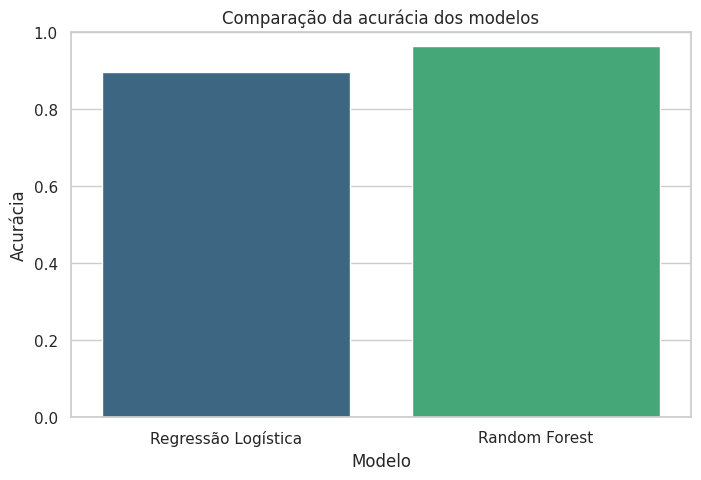

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=resultados,
    x="Modelo",
    y="Acurácia",
    hue="Modelo",
    legend=False,
    palette="viridis"
)

plt.ylim(0, 1)
plt.title("Comparação da acurácia dos modelos")
plt.ylabel("Acurácia")
plt.xlabel("Modelo")

plt.show()


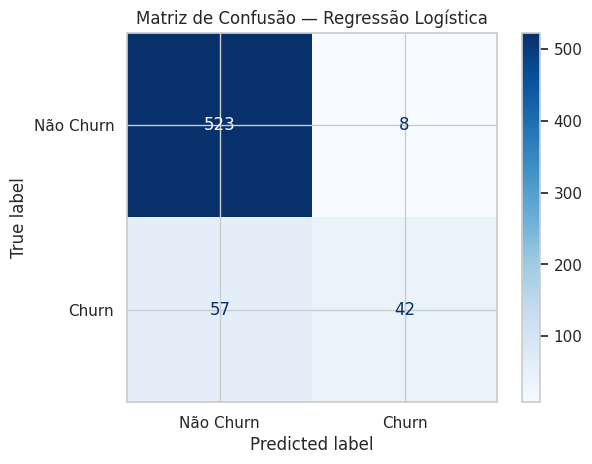

In [51]:
matriz_logistica = confusion_matrix(
    y_test,
    previsoes_logistica
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_logistica,
    display_labels=["Não Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão — Regressão Logística")
plt.show()


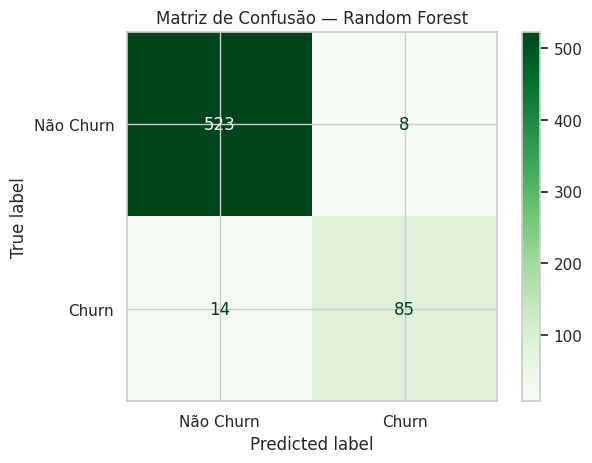

In [52]:
matriz_floresta = confusion_matrix(
    y_test,
    previsoes_floresta
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_floresta,
    display_labels=["Não Churn", "Churn"]
)

disp.plot(cmap="Greens")
plt.title("Matriz de Confusão — Random Forest")
plt.show()


In [53]:
print("=== Regressão Logística ===")
print(
    classification_report(
        y_test,
        previsoes_logistica,
        target_names=["Não Churn", "Churn"]
    )
)


=== Regressão Logística ===
              precision    recall  f1-score   support

   Não Churn       0.90      0.98      0.94       531
       Churn       0.84      0.42      0.56        99

    accuracy                           0.90       630
   macro avg       0.87      0.70      0.75       630
weighted avg       0.89      0.90      0.88       630



In [54]:
cliente_exemplo = X_test.iloc[[0]]

print("Dados do cliente:")
display(cliente_exemplo)

print(
    "Classe real:",
    y_test.iloc[0]
)

print(
    "Previsão - Regressão Logística:",
    modelo_logistico.predict(cliente_exemplo)[0]
)

print(
    "Previsão - Random Forest:",
    modelo_floresta.predict(cliente_exemplo)[0]
)


Dados do cliente:


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
3036,2,0,36,0,1260,39,20,22,3,1,2,30,131.96


Classe real: 0
Previsão - Regressão Logística: 0
Previsão - Random Forest: 0


## 3.3 Desenvolvimento

Crie abaixo as células de Markdown e código necessárias. Organize o trabalho com subtítulos claros e mantenha os resultados da última execução visíveis na entrega.

In [55]:
# Inicie aqui a implementação do desafio.
# Adicione novas células conforme a estrutura solicitada.

In [56]:
df_ex3.dtypes.value_counts()

,count
int64,13
float64,1


## 3.4 Conclusão técnica do grupo

Apresente uma conclusão com:

- síntese dos padrões observados na análise exploratória;
- comparação da acurácia dos modelos;
- leitura básica da matriz de confusão;
- limitações do conjunto de dados e da modelagem;
- melhorias que seriam testadas em uma próxima versão.

Não declare que o modelo “comprova”, “garante” ou “prevê perfeitamente” um resultado.

Conclusão técnica

A análise exploratória do conjunto de dados Iranian Churn permitiu observar diferenças entre os clientes que permaneceram na empresa e aqueles que apresentaram evasão. As visualizações indicaram que algumas características relacionadas ao perfil e à utilização dos serviços podem apresentar comportamentos diferentes entre as classes. Também foram verificadas as dimensões, os tipos das variáveis, possíveis valores ausentes, registros duplicados e a distribuição da variável-alvo.

Para a modelagem, os dados foram separados em variáveis preditoras (X) e variável-alvo (Churn). Em seguida, foram divididos em conjuntos de treinamento e teste, utilizando estratificação para manter uma distribuição semelhante das classes. O pré-processamento foi realizado de acordo com os tipos das variáveis, incluindo padronização das variáveis numéricas e codificação das variáveis categóricas.

Foram avaliados dois algoritmos: Regressão Logística e Random Forest. A Regressão Logística apresentou acurácia de [INSERIR VALOR], enquanto a Random Forest apresentou acurácia de [INSERIR VALOR]. Dessa forma, considerando exclusivamente a acurácia obtida no conjunto de teste, o modelo selecionado foi [INSERIR MODELO].

A matriz de confusão permitiu observar os acertos e erros cometidos pelo modelo. Em particular, os falsos negativos representam clientes que foram classificados como não evasores, mas que pertenciam à classe Churn. Esse tipo de erro pode ser relevante para uma empresa de telecomunicações, pois representa clientes que poderiam deixar a empresa sem serem identificados previamente pelo modelo.

Os resultados devem ser interpretados considerando algumas limitações. O conjunto de dados possui características específicas e pode não representar todos os clientes ou empresas de telecomunicações. Além disso, a avaliação foi realizada utilizando uma divisão específica entre treinamento e teste, e a acurácia isoladamente não descreve completamente o desempenho de um classificador, principalmente quando existe diferença entre as quantidades das classes.

Como melhorias futuras, poderiam ser testados outros algoritmos, ajuste de hiperparâmetros, validação cruzada e técnicas para lidar com eventual desbalanceamento das classes. Também seria interessante avaliar métricas como precisão, recall e F1-score e investigar quais variáveis apresentam maior contribuição para a identificação de clientes com risco de evasão.

# Parte 2 — Apresentação e demonstração

O grupo deverá demonstrar a implementação escolhida no Exercício 3. A apresentação deve evidenciar compreensão do processo, e não apenas mostrar o notebook pronto.

## Roteiro sugerido

1. **Problema e dados:** tema, fonte, unidade de análise, variável-alvo e classes.
2. **Análise exploratória:** dois ou três achados relevantes e possíveis problemas da base.
3. **Pré-processamento:** o que foi feito e por que foi necessário.
4. **Modelagem:** algoritmos escolhidos e forma de divisão dos dados.
5. **Resultados:** comparação da acurácia e leitura da matriz de confusão.
6. **Decisão:** modelo selecionado, limitações e melhorias futuras.

## Durante a demonstração

- execute ou apresente células essenciais do fluxo;
- explique uma transformação de pré-processamento;
- mostre como as previsões são geradas;
- interprete ao menos um erro da matriz de confusão;
- responda às perguntas do professor sobre decisões do grupo.

> Todos os integrantes podem ser questionados sobre qualquer parte entregue.

# Critérios de avaliação

## Parte 1 — Implementação: 70 pontos

| Critério | Pontos |
|---|---:|
| Carga, compreensão e organização dos dados | 10 |
| Análise exploratória e qualidade das interpretações | 15 |
| Pré-processamento básico dos dados | 15 |
| Treinamento correto e comparação dos modelos | 15 |
| Acurácia, matriz de confusão e interpretação | 10 |
| Conclusão, limitações e organização do notebook | 5 |

## Parte 2 — Apresentação: 30 pontos

| Critério | Pontos |
|---|---:|
| Clareza na contextualização do problema e dos dados | 5 |
| Demonstração do fluxo implementado | 10 |
| Interpretação dos resultados e justificativa das decisões | 10 |
| Participação e domínio do grupo | 5 |

**Total: 100 pontos**

# Checklist final

- [ ] Identificação do grupo preenchida.
- [ ] Exercício 2 concluído e interpretado.
- [ ] Exercício 3 desenvolvido com um dos quatro temas.
- [ ] CSV utilizado está acessível ou sua obtenção está documentada.
- [ ] Notebook executado do início ao fim sem erros.
- [ ] Resultados e gráficos permanecem visíveis.
- [ ] Dois ou mais modelos foram comparados.
- [ ] Acurácia e matriz de confusão foram interpretadas.
- [ ] Conclusão inclui limitações.
- [ ] Grupo está preparado para demonstrar e explicar a implementação.